<a href="https://colab.research.google.com/github/IrineuBovoJunior398/P-S_GRADUA-O_IA_UTFPR/blob/main/C%C3%B3pia_de_AULA2_5_REGRESSORES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.datasets import load_diabetes
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict

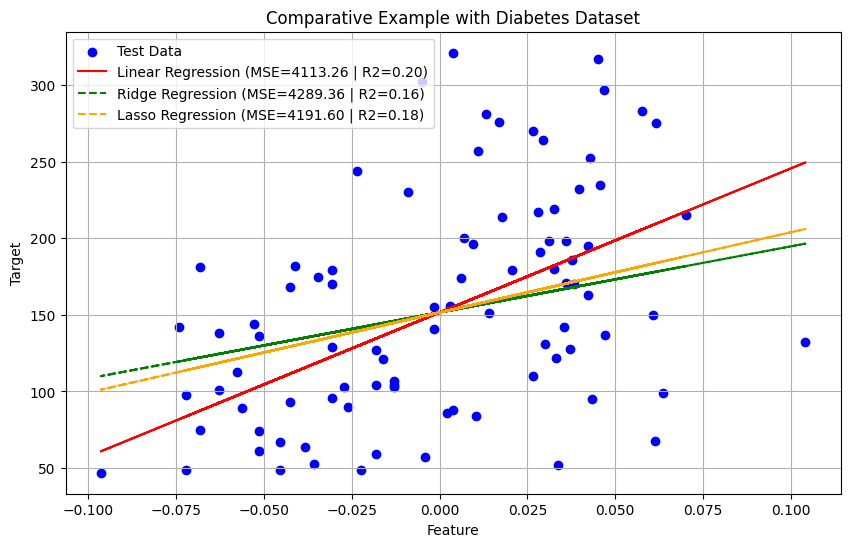

In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt


# Load the diabetes dataset
diabetes = load_diabetes()
X = diabetes.data[:, np.newaxis, 8] # Use only one feature for simplicity
y = diabetes.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Fit simple linear regression model
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

# Fit ridge regression model
ridge = Ridge(alpha=1)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

# Fit lasso regression model
lasso = Lasso(alpha=1) # Regularization strenght
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_r2 = r2_score(y_test, lasso_pred)

# Plot the data points and regression lines
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Test Data')
plt.plot(X_test, lr_pred, color='red', label='Linear Regression (MSE={:.2f} | R2={:.2f})'.format(lr_mse, lr_r2))
plt.plot(X_test, ridge_pred, color='green', linestyle='--', label='Ridge Regression (MSE={:.2f} | R2={:.2f})'.format(ridge_mse, ridge_r2))
plt.plot(X_test, lasso_pred, color='orange', linestyle='--', label='Lasso Regression (MSE={:.2f} | R2={:.2f})'.format(lasso_mse, lasso_r2))
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('Comparative Example with Diabetes Dataset')
plt.legend()
plt.grid(True)
plt.show()

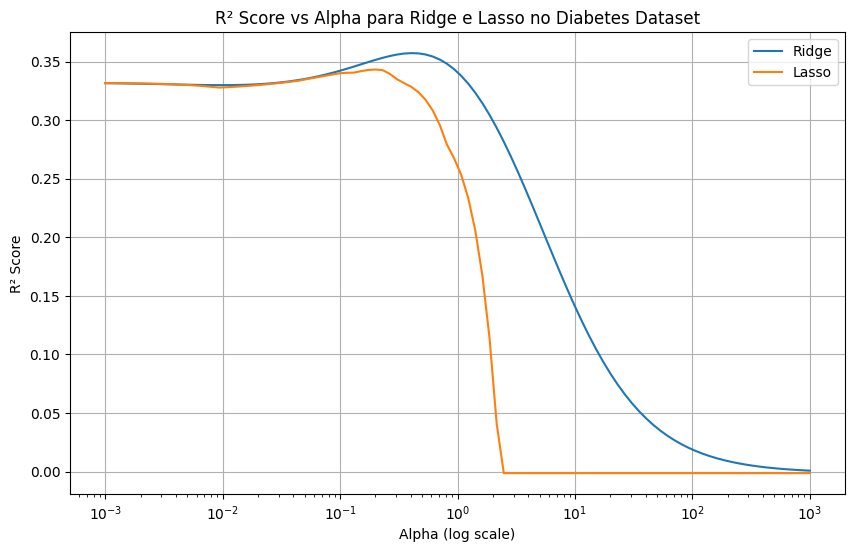

Melhor alpha para Ridge: 0.4037, R²: 0.3573
Melhor alpha para Lasso: 0.2009, R²: 0.3433


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score

# Carregar o dataset diabetes
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

# Dividir os dados em treino e teste (80/20, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Gerar valores de alpha de 10^-3 a 10^3 com 100 pontos
alphas = np.logspace(-3, 3, 100)

# Listas para armazenar os scores R²
ridge_r2_scores = []
lasso_r2_scores = []

# Loop para variar alpha e calcular R² para Ridge e Lasso
for alpha_val in alphas:  # Usar alpha_val para evitar confusão com a lista alphas
    # Ridge
    ridge = Ridge(alpha=alpha_val)
    ridge.fit(X_train, y_train)
    pred_ridge = ridge.predict(X_test)
    ridge_r2_scores.append(r2_score(y_test, pred_ridge))

    # Lasso
    lasso = Lasso(alpha=alpha_val)
    lasso.fit(X_train, y_train)
    pred_lasso = lasso.predict(X_test)
    lasso_r2_scores.append(r2_score(y_test, pred_lasso))

# Plotar os resultados
plt.figure(figsize=(10, 6))
plt.semilogx(alphas, ridge_r2_scores, label='Ridge')  # Usar alphas correto para o eixo x
plt.semilogx(alphas, lasso_r2_scores, label='Lasso')  # Usar alphas correto para o eixo x
plt.title('R² Score vs Alpha para Ridge e Lasso no Diabetes Dataset')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R² Score')
plt.legend()
plt.grid(True)
plt.show()

# Encontrar e imprimir o melhor alpha e R² para Ridge
best_ridge_idx = np.argmax(ridge_r2_scores)
best_ridge_alpha = alphas[best_ridge_idx]
best_ridge_r2 = ridge_r2_scores[best_ridge_idx]
print(f"Melhor alpha para Ridge: {best_ridge_alpha:.4f}, R²: {best_ridge_r2:.4f}")

# Encontrar e imprimir o melhor alpha e R² para Lasso
best_lasso_idx = np.argmax(lasso_r2_scores)
best_lasso_alpha = alphas[best_lasso_idx]
best_lasso_r2 = lasso_r2_scores[best_lasso_idx]
print(f"Melhor alpha para Lasso: {best_lasso_alpha:.4f}, R²: {best_lasso_r2:.4f}")


Polynomial Degree = 5
     MSE: 3612.6032763082526
     R2:  0.8629856264563655



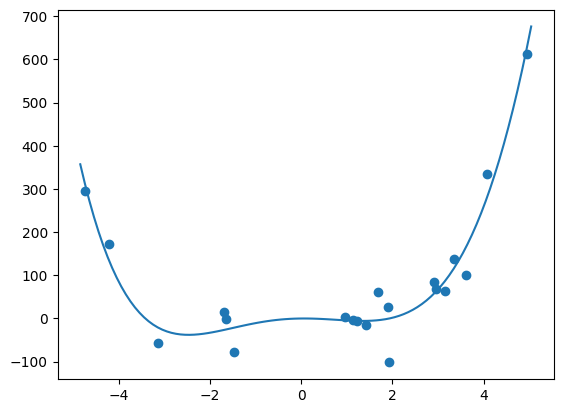

In [ ]:
# Function to generate polynominal data
def generate_polynominal_data(n_samples, noise):
  X = np.random.uniform(-5, 5, size=(n_samples, 1))
  y = (0.8*X**4 + X**3 - 2*X**2 + X + 3) + noise*100 * np.random.randn(n_samples, 1)
  return X, y

# Generate polynominal data
n_samples = 100
noise = 0.5
X, y = generate_polynominal_data(n_samples, noise)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear model with PolynominalFeatures degree=2
for i in range(1, 6):
  poly = PolynomialFeatures(degree=i)
  X_poly_train = poly.fit_transform(X_train)
  X_poly_test = poly.transform(X_test[:])


lr_poly = LinearRegression()
lr_poly.fit(X_poly_train, y_train)
y_pred_poly = lr_poly.predict(X_poly_test)
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print()
print("Polynomial Degree =", i)
print("     MSE:", mse_poly)
print("     R2: ", r2_poly)
print()
plt.figure()
mymodel = np.poly1d(np.polyfit(X_test.ravel(), y_test.ravel(), i))
myline = np.linspace(min(X_test.ravel()) - 0.1, max(X_test.ravel()) + 0.1, 100)
plt.scatter(X_test, y_test)
plt.plot(myline, mymodel(myline))
plt.show()

Resultados Cross-Validation (10-fold):
Linear: 0.462 (±0.294)
Lasso: 0.321 (±0.182)
Ridge: 0.405 (±0.217)


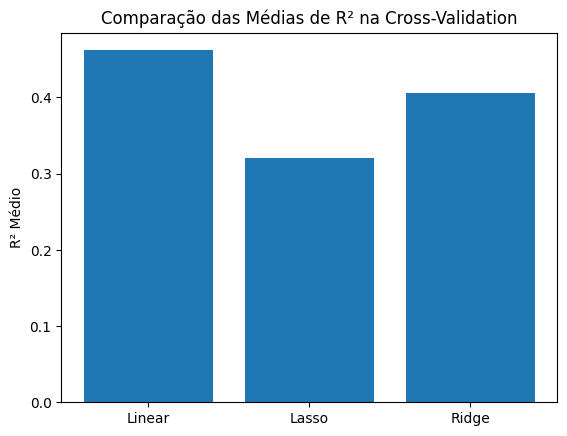

In [ ]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import matplotlib.pyplot as plt

# Carregando o dataset diabetes
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

# Realizando cross-validation com 10 folds para cada modelo
# Corrigido: Adicionados todos os imports necessários, incluindo numpy, load_diabetes, cross_val_score, LinearRegression, Ridge, Lasso e plt para o gráfico.
# Corrigido: Usado '=' em vez de '-' para atribuição (ex: lr_r2 = cross_val_score...).
# Corrigido: scoring='r2' com aspas simples corretas.
# Corrigido: cv=10 definido corretamente.
lr_r2 = cross_val_score(LinearRegression(), X, y, cv=10, scoring='r2')
lasso_r2 = cross_val_score(Lasso(), X, y, cv=10, scoring='r2')
ridge_r2 = cross_val_score(Ridge(), X, y, cv=10, scoring='r2')

# Imprimindo os resultados
print("Resultados Cross-Validation (10-fold):")
print(f"Linear: {lr_r2.mean():.3f} (±{lr_r2.std()*2:.3f})")
print(f"Lasso: {lasso_r2.mean():.3f} (±{lasso_r2.std()*2:.3f})")
print(f"Ridge: {ridge_r2.mean():.3f} (±{ridge_r2.std()*2:.3f})")

# Gráfico de barras para comparar as médias dos R²
models = ['Linear', 'Lasso', 'Ridge']
means = [lr_r2.mean(), lasso_r2.mean(), ridge_r2.mean()]
plt.bar(models, means)
plt.ylabel('R² Médio')
plt.title('Comparação das Médias de R² na Cross-Validation')
plt.show()



R² médio para LinearRegression: 0.46
R² médio para Ridge: 0.41
R² médio para Lasso: 0.33


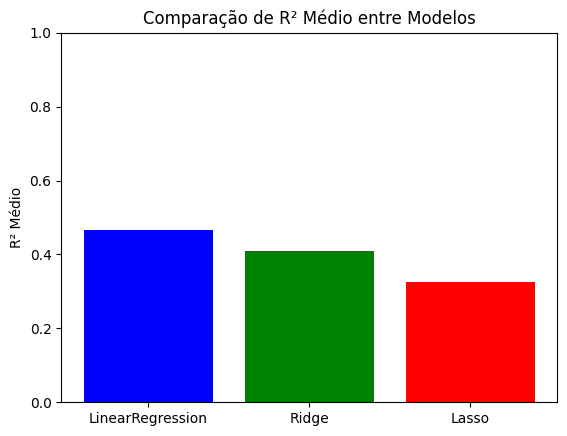

In [ ]:
# Imports necessários
# Corrigido: Incluídos todos os imports especificados, incluindo numpy, sklearn.datasets.load_diabetes, etc.
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import matplotlib.pyplot as plt

# Carregar o dataset diabetes
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

# Definir KFold personalizado
# Corrigido: KFold importado corretamente, parâmetros com = (não -), e cv=kf usado com vírgula em cross_val_score.
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Calcular R² para LinearRegression
lr_r2 = cross_val_score(LinearRegression(), X, y, cv=kf, scoring='r2')

# Calcular R² para Ridge
ridge_r2 = cross_val_score(Ridge(), X, y, cv=kf, scoring='r2')

# Calcular R² para Lasso
lasso_r2 = cross_val_score(Lasso(), X, y, cv=kf, scoring='r2')

# Calcular médias
lr_mean = np.mean(lr_r2)
ridge_mean = np.mean(ridge_r2)
lasso_mean = np.mean(lasso_r2)

# Prints modernos com f-strings
print(f'R² médio para LinearRegression: {lr_mean:.2f}')
print(f'R² médio para Ridge: {ridge_mean:.2f}')
print(f'R² médio para Lasso: {lasso_mean:.2f}')

# Bar plot comparando as médias
models = ['LinearRegression', 'Ridge', 'Lasso']
means = [lr_mean, ridge_mean, lasso_mean]
plt.bar(models, means, color=['blue', 'green', 'red'])
plt.ylabel('R² Médio')
plt.title('Comparação de R² Médio entre Modelos')
plt.ylim(0, 1)  # Ajuste para melhor visualização
plt.show()



MSE: 2999.04
R2: 0.49
Valores aproximados esperados: MSE ~2900-3100, R2 ~0.51


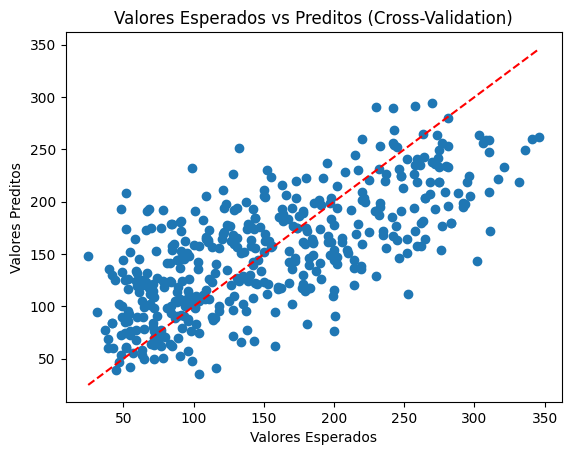

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Carregando o dataset diabetes
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

# Criando o modelo de regressão linear
model = LinearRegression()

# Fazendo previsões com cross-validation (cv=10)
predictions = cross_val_predict(model, X, y, cv=10)

# Calculando métricas
mse = mean_squared_error(y, predictions)
r2 = r2_score(y, predictions)

# Imprimindo os resultados com f-strings
print(f'MSE: {mse:.2f}')
print(f'R2: {r2:.2f}')

# Valores aproximados reais: MSE entre 2900-3100, R2 cerca de 0.51
print(f'Valores aproximados esperados: MSE ~2900-3100, R2 ~0.51')

# Criando o gráfico scatter
plt.scatter(y, predictions)

# Linha de referência y=x
y_ref = np.linspace(min(y), max(y), 100)
plt.plot(y_ref, y_ref, color='red', linestyle='--')

# Labels e título
plt.xlabel('Valores Esperados')
plt.ylabel('Valores Preditos')
plt.title('Valores Esperados vs Preditos (Cross-Validation)')

# Mostrando o gráfico
plt.show()





In [ ]:
# Gerando o modelo com todos os dados
model = LinearRegression()
model.fit(X, y)

# Gerando o gráfico
print("Intercept: ", model.intercept_)
print("Coeficientes: ", model.coef_)


Intercept:  152.13348416289597
Coeficientes:  [ -10.0098663  -239.81564367  519.84592005  324.3846455  -792.17563855
  476.73902101  101.04326794  177.06323767  751.27369956   67.62669218]


In [ ]:
fnames = diabetes.feature_names
print("Coeficientes das variáveis independentes:")
for variavel, coeficiente in dict(zip(fnames, model.coef_)).items():
    print(f"{variavel}: {coeficiente}")


Coeficientes das variáveis independentes:
age: -10.009866299810684
sex: -239.81564367242237
bmi: 519.84592005446
bp: 324.38464550232356
s1: -792.1756385522286
s2: 476.7390210052569
s3: 101.04326793803338
s4: 177.06323767134643
s5: 751.2736995571034
s6: 67.62669218370515


Intercept: 152.1335
Coeficientes das variáveis independentes:
age: 29.4661
sex: -83.1543
bmi: 306.3527
bp: 201.6277
s1: 5.9096
s2: -29.5155
s3: -152.0403
s4: 117.3117
s5: 262.9443
s6: 111.8790


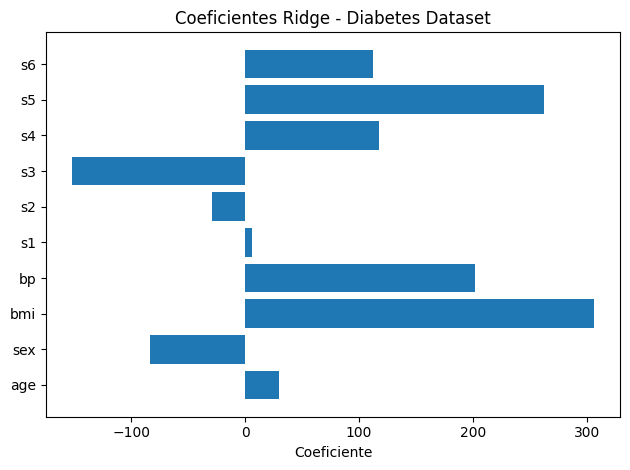

In [ ]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt

# Load the diabetes dataset
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
fnames = diabetes.feature_names

# Create and fit the Ridge model
model = Ridge()
model.fit(X, y)

# Print the intercept
print(f"Intercept: {model.intercept_:.4f}")

# Print the coefficients
print("Coeficientes das variáveis independentes:")
for nome, coef in zip(fnames, model.coef_):
    print(f"{nome}: {coef:.4f}")

# Plot the coefficients
plt.barh(fnames, model.coef_)
plt.xlabel('Coeficiente')
plt.title('Coeficientes Ridge - Diabetes Dataset')
plt.tight_layout()
plt.show()

Intercept: 152.1335
Coeficientes das variáveis independentes:
age: 0.0000
sex: -0.0000
bmi: 367.7039
bp: 6.2989
s1: 0.0000
s2: 0.0000
s3: -0.0000
s4: 0.0000
s5: 307.6054
s6: 0.0000


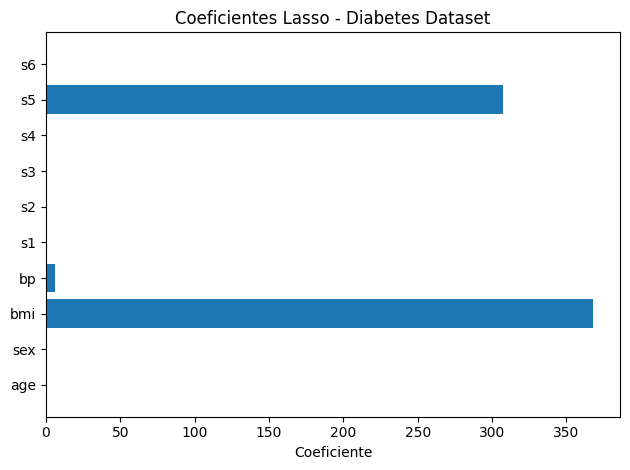

In [ ]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Lasso
import matplotlib.pyplot as plt

# Load the dataset
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
fnames = diabetes.feature_names

# Create and fit the model
model = Lasso()
model.fit(X, y)

# Print intercept
print(f"Intercept: {model.intercept_:.4f}")

# Print coefficients
print("Coeficientes das variáveis independentes:")
for nome, coef in zip(fnames, model.coef_):
    print(f"{nome}: {coef:.4f}")

# Plot bar chart
plt.barh(fnames, model.coef_)
plt.xlabel('Coeficiente')
plt.title('Coeficientes Lasso - Diabetes Dataset')
plt.tight_layout()
plt.show()
